# Visualizing the Loss Function

Loss functions in machine learning are often defined in very high-dimensional spaces.

For example, in CIFAR-10, a linear classifier has a weight matrix:

$$
W \in \mathbb{R}^{10 \times 3073}
$$

which corresponds to **30,730 parameters**, making direct visualization very difficult.

## 1. Intuition via 1D and 2D Slices

To understand the structure of the loss function, we can slice the high-dimensional space.
### 1D Slice (Along a Ray)

We fix a weight matrix $$W$$ and choose a random direction $$W_1$$.

Then we evaluate:

$$
L(W + aW_1)
$$

for different values of $$a$$.

- x-axis → $$a$$  
- y-axis → loss value  
### 2D Slice (Along a Plane)

We extend this idea by using two directions $$W_1$$ and $$W_2$$:

$$
L(W + aW_1 + bW_2)
$$

- x-axis → $$a$$  
- y-axis → $$b$$  
- color → loss value  

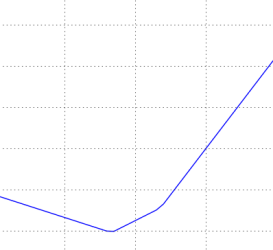
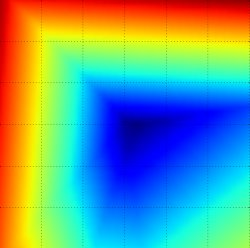
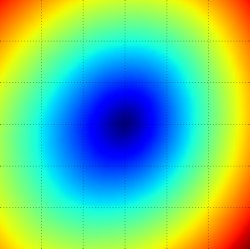

Add a visualization of the loss landscape:

- Left: 1D plot (loss vs a)
- Middle: 2D slice for a single example
- Right: 2D slice for multiple examples
- Colors: Blue = low loss, Red = high loss

## 2. Piecewise Linear Structure of the Loss

For a single example, the Multiclass SVM loss is:

$$
L_i = \sum_{j \neq y_i} \max\left(0, w_j^T x_i - w_{y_i}^T x_i + 1 \right)
$$

### Key Observations

- Each term is linear in $$W$$  
- The $$\max(0, \cdot)$$ introduces a threshold  
- This creates "kinks" in the function  
- Therefore, the loss is **piecewise linear**

## 3. Simple 1D Example

Consider a simple dataset:

- 3 data points  
- 3 classes  
- 1-dimensional inputs  

The total loss is:

$$
L = \frac{1}{3}(L_0 + L_1 + L_2)
$$
$$
L_0 = \max(0, w_1 x_0 - w_0 x_0 + 1) + \max(0, w_2 x_0 - w_0 x_0 + 1)
$$

$$
L_1 = \max(0, w_0 x_1 - w_1 x_1 + 1) + \max(0, w_2 x_1 - w_1 x_1 + 1)
$$

$$
L_2 = \max(0, w_0 x_2 - w_2 x_2 + 1) + \max(0, w_1 x_2 - w_2 x_2 + 1)
$$
Each term is either:

- independent of a weight  
- or a linear function of that weight, clipped at zero  

This creates a piecewise linear structure.

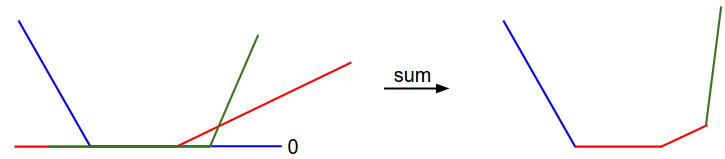

Add a 1D visualization of the loss:

- x-axis: a single weight value  
- y-axis: loss  
- multiple linear segments joined together  
- flat regions where loss = 0  
- sharp corners (kinks)

This illustrates how the SVM loss is built from multiple hinge-like components.

## 4. Convexity of the SVM Loss

The SVM loss has a bowl-shaped structure, which indicates that it is a convex function.
### Why this matters

- Convex functions have no local minima  
- Optimization is easier  
- Many efficient algorithms exist  

## 5. Non-Convexity in Neural Networks

When we use Neural Networks:

- The loss function becomes non-convex  
- The landscape becomes complex and irregular  
- Many local minima can exist  

## 6. Non-Differentiability and Subgradients

Because of the max operation, the loss function has kinks.


At these points:

- The gradient is not defined  
- However, a subgradient exists  

In practice, we use subgradients and treat them like gradients.

# Optimization

The loss function allows us to measure how good a particular set of weights $$W$$ is.

The goal of optimization is:

$$
\min_W L(W)
$$

That is, we want to find the weights that minimize the loss function.

---

In this section, we develop strategies to optimize the loss.

Even though SVM loss is convex, our goal is to eventually optimize Neural Networks, where convex optimization tools are not sufficient.

In [6]:
import os
import pickle
import numpy as np

def load_batch(file_path):
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
        X = batch[b"data"]
        y = np.array(batch[b"labels"])
    return X, y

def load_cifar10(root_dir, num_train=5000, num_test=1000):
    X_train_list = []
    y_train_list = []

    for i in range(1, 6):
        X_batch, y_batch = load_batch(os.path.join(root_dir, f"data_batch_{i}"))
        X_train_list.append(X_batch)
        y_train_list.append(y_batch)

    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)

    X_test, y_test = load_batch(os.path.join(root_dir, "test_batch"))

    # take small subset for speed
    X_train = X_train[:num_train]
    y_train = y_train[:num_train]
    X_test = X_test[:num_test]
    y_test = y_test[:num_test]

    return X_train, y_train, X_test, y_test
DATA_PATH = "/home/efeak/VSCodeProjects/cs231n/datasets/cifar-10-batches-py"

X_train, y_train, X_test, y_test = load_cifar10(
    DATA_PATH,
    num_train=5000,
    num_test=1000
)

# normalize pixel values
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# add bias column
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])

# transpose: columns are examples
X_train = X_train.T
X_test = X_test.T

print("X_train:", X_train.shape)  # (3073, 5000)
print("y_train:", y_train.shape)  # (5000,)
print("X_test:", X_test.shape)    # (3073, 1000)
print("y_test:", y_test.shape)    # (1000,)

def L(X, y, W, delta=1.0):
    """
    Multiclass SVM loss.

    X shape: (D, N)
    y shape: (N,)
    W shape: (C, D)
    """

    scores = W.dot(X)  # (C, N)

    correct_scores = scores[y, np.arange(X.shape[1])]  # (N,)

    margins = scores - correct_scores + delta
    margins[y, np.arange(X.shape[1])] = 0

    margins = np.maximum(0, margins)

    loss = np.mean(np.sum(margins, axis=0))

    return loss

def accuracy(X, y, W):
    scores = W.dot(X)
    y_pred = np.argmax(scores, axis=0)
    return np.mean(y_pred == y)

/tmp/ipykernel_21539/1987185108.py:7: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding="bytes")


X_train: (3073, 5000)
y_train: (5000,)
X_test: (3073, 1000)
y_test: (1000,)


## Strategy #1: Random Search (Very Bad Idea)

A naive idea:

- Try many random weights $$W$$
- Evaluate the loss
- Keep the best one

This is extremely inefficient but easy to implement.

In [22]:
bestloss = float("inf")
bestW = None

for num in range(100):
    W = np.random.randn(10, 3073) * 0.0001
    loss = L(X_train, y_train, W)

    if loss < bestloss:
        bestloss = loss
        bestW = W

    print(f"attempt {num}: loss = {loss:.4f}, best = {bestloss:.4f}")

print("Best train loss:", bestloss)


attempt 0: loss = 9.0006, best = 9.0006
attempt 1: loss = 9.0001, best = 9.0001
attempt 2: loss = 9.0008, best = 9.0001
attempt 3: loss = 8.9998, best = 8.9998
attempt 4: loss = 9.0041, best = 8.9998
attempt 5: loss = 9.0010, best = 8.9998
attempt 6: loss = 9.0000, best = 8.9998
attempt 7: loss = 9.0010, best = 8.9998
attempt 8: loss = 8.9979, best = 8.9979
attempt 9: loss = 8.9996, best = 8.9979
attempt 10: loss = 9.0011, best = 8.9979
attempt 11: loss = 8.9996, best = 8.9979
attempt 12: loss = 9.0019, best = 8.9979
attempt 13: loss = 8.9994, best = 8.9979
attempt 14: loss = 9.0010, best = 8.9979
attempt 15: loss = 9.0015, best = 8.9979
attempt 16: loss = 8.9993, best = 8.9979
attempt 17: loss = 9.0002, best = 8.9979
attempt 18: loss = 9.0014, best = 8.9979
attempt 19: loss = 8.9992, best = 8.9979
attempt 20: loss = 8.9987, best = 8.9979
attempt 21: loss = 9.0020, best = 8.9979
attempt 22: loss = 9.0011, best = 8.9979
attempt 23: loss = 9.0011, best = 8.9979
attempt 24: loss = 8.9992,

### Evaluation on Test Set

We can evaluate the best weights on test data:

- Compute scores
- Pick the class with highest score
- Measure accuracy

In [23]:
scores = bestW.dot(X_test)
Y_pred = np.argmax(scores, axis=0)

accuracy = np.mean(Y_pred == y_test)  
print(accuracy)

0.109


### Observation

- Random guessing gives ~10% accuracy (for 10 classes)
- Random search achieves ~13.8%

This is slightly better, but still very inefficient.

---

Random search is:

- slow  
- wasteful  
- not scalable  

## Core Idea: Iterative Refinement

Instead of searching randomly:

- Start with a random $$W$$
- Improve it step by step

---

We don't try to solve the whole problem at once.

Instead:

> Make small improvements repeatedly

### Blindfolded Hiker Analogy

Imagine:

- You are standing on a hill
- You are blindfolded
- Your goal is to reach the bottom

Each position corresponds to a weight vector $$W$$  
The height corresponds to the loss value

---

Goal:

> Move in a direction that decreases the loss


## Strategy #2: Random Local Search

Instead of trying completely random weights:

- Start from a current $$W$$
- Try small random changes $$\delta W$$
- Keep the change if it improves the loss

In [20]:
W = np.random.randn(10, 3073) * 0.001
bestloss = L(X_train, y_train, W)
bestW = W.copy()

step_size = 0.0001

for i in range(100):
    Wtry = W + np.random.randn(10, 3073) * step_size
    loss = L(X_train, y_train, Wtry)

    if loss < bestloss:
        W = Wtry
        bestW = Wtry.copy()
        bestloss = loss

    print(f"iter {i}: best loss = {bestloss:.4f}")

print("Best train loss:", bestloss)
accuracy = np.mean(np.argmax(bestW.dot(X_test), axis=0) == y_test)
print("accuracy:", accuracy)

iter 0: best loss = 9.0074
iter 1: best loss = 9.0074
iter 2: best loss = 9.0074
iter 3: best loss = 9.0067
iter 4: best loss = 9.0036
iter 5: best loss = 9.0036
iter 6: best loss = 9.0020
iter 7: best loss = 9.0020
iter 8: best loss = 9.0000
iter 9: best loss = 8.9977
iter 10: best loss = 8.9953
iter 11: best loss = 8.9936
iter 12: best loss = 8.9936
iter 13: best loss = 8.9936
iter 14: best loss = 8.9936
iter 15: best loss = 8.9936
iter 16: best loss = 8.9936
iter 17: best loss = 8.9936
iter 18: best loss = 8.9930
iter 19: best loss = 8.9930
iter 20: best loss = 8.9928
iter 21: best loss = 8.9910
iter 22: best loss = 8.9910
iter 23: best loss = 8.9910
iter 24: best loss = 8.9906
iter 25: best loss = 8.9906
iter 26: best loss = 8.9906
iter 27: best loss = 8.9906
iter 28: best loss = 8.9903
iter 29: best loss = 8.9892
iter 30: best loss = 8.9883
iter 31: best loss = 8.9883
iter 32: best loss = 8.9883
iter 33: best loss = 8.9883
iter 34: best loss = 8.9883
iter 35: best loss = 8.9874
it

### Observation

- Accuracy improves to ~11.4%(As the subset is small, it produces slightly poorer results )
- Better than pure random search

However:

- Still inefficient  
- Still random  

## Strategy #3: Following the Gradient

Instead of guessing directions randomly:

👉 We compute the best direction mathematically

This direction is called the **gradient**.

### Key Idea

The gradient points in the direction of:

> steepest increase in the loss

So:

- To minimize loss → move in the opposite direction

### Intuition (Hiker Analogy)

Instead of random steps:

- Feel the slope under your feet
- Move in the steepest downhill direction

This is much more efficient than random guessing.

## Derivative (1D Case)

For a function $$f(x)$$, the derivative is:

$$
\frac{df(x)}{dx} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}
$$

This represents:

- the slope  
- the rate of change  

## Gradient (Multi-Dimensional Case)

When $$f$$ takes a vector input:

$$
f(x_1, x_2, ..., x_n)
$$

We compute **partial derivatives**:

$$
\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, ..., \frac{\partial f}{\partial x_n}
$$

---

The gradient is:

$$
\nabla f = 
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

---

It tells us how the function changes in each dimension.

# Computing the Gradient

There are two ways to compute the gradient:

- Numerical gradient (slow, approximate, easy)
- Analytic gradient (fast, exact, requires calculus)

---

We will explore both approaches.

## Numerical Gradient (Finite Differences)

We can approximate the gradient using the definition of derivative:

$$
\frac{df(x)}{dx} \approx \frac{f(x + h) - f(x)}{h}
$$

where $$h$$ is a very small number.

In [24]:
def eval_numerical_gradient(f, x):
    """
    Compute numerical gradient of f at x
    """

    fx = f(x)
    grad = np.zeros(x.shape)
    h = 1e-5

    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])

    while not it.finished:
        ix = it.multi_index

        old_value = x[ix]
        x[ix] = old_value + h
        fxh = f(x)
        x[ix] = old_value

        grad[ix] = (fxh - fx) / h

        it.iternext()

    return grad

### Intuition

We compute the gradient by:

- Changing one parameter slightly
- Measuring how much the loss changes
- Repeating for all parameters

---

The result is a vector of slopes for each dimension.

### Practical Considerations

- The gradient is defined as $$h \to 0$$
- In practice, we use a small value like:

$$
h = 10^{-5}
$$

---

A better approximation is the centered difference:

$$
\frac{f(x + h) - f(x - h)}{2h}
$$

## Applying Numerical Gradient to CIFAR-10

We define a function that depends only on weights:

$$
f(W) = L(X_{train}, y_{train}, W)
$$

In [27]:
def CIFAR10_loss_fun(W):
    return L(X_train, y_train, W)

W = np.random.randn(10, 3073) * 0.001

df = eval_numerical_gradient(CIFAR10_loss_fun, W)

KeyboardInterrupt: 

### What does the gradient tell us?

The gradient gives:

- direction of steepest increase  
- to minimize loss → move in the opposite direction  

$$
W_{new} = W - \eta \nabla L
$$

In [28]:
loss_original = CIFAR10_loss_fun(W)
print("original loss:", loss_original)

for step_size_log in [-10, -9, -8, -7, -6, -5, -4, -3, -2, -1]:
    step_size = 10 ** step_size_log

    W_new = W - step_size * df
    loss_new = CIFAR10_loss_fun(W_new)

    print(f"step size {step_size:.1e}: loss = {loss_new}")

original loss: 8.995452286280438


NameError: name 'df' is not defined

### Observation

- Small step sizes → slow but stable improvement  
- Large step sizes → risk of overshooting  

---

Choosing step size (learning rate) is critical.

### Key Insight

The gradient tells us **direction**, not **distance**.

We must choose how far to move.


## Problem of Numerical Gradient

- Very slow  
- Requires evaluating loss many times  

---

If we have $$30730$$ parameters:

- Need ~30730 evaluations per update  

---

Not scalable for large models.

## Analytic Gradient (Using Calculus)

Instead of approximating, we derive the gradient directly.

This gives:

- exact result  
- much faster computation  

### SVM Loss (Single Example)

$$
L_i = \sum_{j \neq y_i} \max(0, w_j^T x_i - w_{y_i}^T x_i + \Delta)
$$
### Gradient for Correct Class

$$
\nabla_{w_{y_i}} L_i =
-\left(\sum_{j \neq y_i} \mathbb{1}(w_j^T x_i - w_{y_i}^T x_i + \Delta > 0)\right) x_i
$$
### Gradient for Incorrect Classes

$$
\nabla_{w_j} L_i =
\mathbb{1}(w_j^T x_i - w_{y_i}^T x_i + \Delta > 0) \cdot x_i
$$
### Intuition

- For incorrect classes:
  - If margin is violated → push weights up  

- For correct class:
  - Push weights down  

---

The model learns to:

- increase correct class score  
- decrease incorrect class scores  


## Gradient Check

In practice:

- compute analytic gradient  
- compare with numerical gradient  

---

This ensures correctness of implementation.

# Gradient Descent

Now that we can compute the gradient of the loss function, we can use it to optimize the model.

The idea is simple:

1. Compute the gradient
2. Update the weights
3. Repeat



This process is called **Gradient Descent**.

## Vanilla Gradient Descent

The simplest version looks like:

- Use the entire dataset
- Compute the gradient
- Update the weights



Update rule:

$$
W := W - \eta \nabla L
$$

### Key Idea

> Follow the gradient until the loss becomes small.

---

This loop is the core of all Neural Network training.

## Mini-batch Gradient Descent

Instead of using all data:

- Sample a small batch
- Compute gradient only on that batch
- Update weights

### Why does this work?

Because data points are correlated:

- Similar images produce similar gradients
- A small subset is often enough

---

So instead of exact gradient:

- we use an approximation

### Key Insight

> A mini-batch gradient is a good approximation of the full gradient.

---

Benefits:

- Faster updates  
- Less computation  
- Practical for large datasets  

## Stochastic Gradient Descent (SGD)

Extreme case:

- Use only 1 sample

---

$$
\text{batch size} = 1
$$
### Characteristics of SGD

- Very noisy updates  
- Fast but unstable  
- Rarely used directly in practice  
## Practical Usage

In practice:

- "SGD" usually means mini-batch gradient descent  
- Not truly single-sample updates  

## Batch Size

The batch size is a hyperparameter.

Common values:

- 32  
- 64  
- 128  
- 256  

### Why powers of 2?

Because:

- Hardware optimization  
- Faster matrix operations  

## Summary

- Gradient Descent → uses full dataset  
- Mini-batch → faster, approximate  
- SGD → extreme case (1 sample)  

---

All methods follow the same idea:

> Move weights in the direction that reduces loss

## Observation

- Full Gradient Descent is slow  
- Mini-batch is efficient and widely used  
- SGD is noisy but can escape local minima  

---

Mini-batch Gradient Descent is the standard approach in deep learning.